In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# Generate synthetic non-linear data with 3 variables
def generate_data(n_samples=1000):
    X1 = np.random.uniform(-5, 5, n_samples)
    X2 = np.random.uniform(-5, 5, n_samples)
    X3 = np.random.uniform(-5, 5, n_samples)

    # Complex non-linear equation with 3 variables
    y = (2 * np.sin(X1) + 0.5 * X2**2 + 0.3 * X3**3 +
         np.cos(X1 * X2) + np.random.normal(0, 0.2, n_samples))

    X = np.column_stack((X1, X2, X3))
    return X.astype(np.float32), y.reshape(-1, 1).astype(np.float32)

X, y = generate_data(1000)

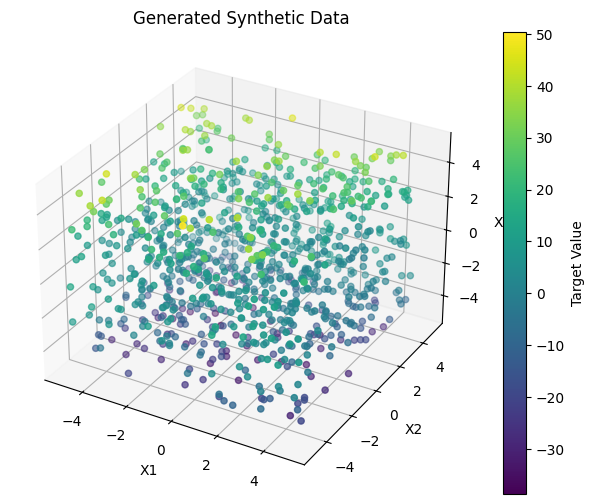

In [3]:
# Plot the generated synthetic data before training
def plot_synthetic_data(X, y):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y[:, 0], cmap='viridis')
    plt.colorbar(scatter, label='Target Value')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('Generated Synthetic Data')
    plt.show()

plot_synthetic_data(X, y)

In [4]:
# Convert data into TensorFlow tensors
X_train = tf.convert_to_tensor(X, dtype=tf.float32)
y_train = tf.convert_to_tensor(y, dtype=tf.float32)

In [5]:
# -----------------------------
# **1. Low-Level TensorFlow (Manual Computation & Backpropagation using einsum)**
# -----------------------------
class LowLevelNN:
    def __init__(self, input_size=3, hidden1_size=64, hidden2_size=32, output_size=1, lr=0.01):
        self.W1 = tf.Variable(tf.random.normal([input_size, hidden1_size]))
        self.b1 = tf.Variable(tf.zeros([hidden1_size]))
        self.W2 = tf.Variable(tf.random.normal([hidden1_size, hidden2_size]))
        self.b2 = tf.Variable(tf.zeros([hidden2_size]))
        self.W3 = tf.Variable(tf.random.normal([hidden2_size, output_size]))
        self.b3 = tf.Variable(tf.zeros([output_size]))
        self.lr = lr

    def forward(self, X):
        hidden1 = tf.nn.relu(tf.einsum('ij,jk->ik', X, self.W1) + self.b1)
        hidden2 = tf.nn.relu(tf.einsum('ij,jk->ik', hidden1, self.W2) + self.b2)
        return tf.einsum('ij,jk->ik', hidden2, self.W3) + self.b3

    def train(self, X, y, epochs=1000):
        for epoch in range(epochs):
            with tf.GradientTape() as tape:
                y_pred = self.forward(X)
                loss = tf.reduce_mean(tf.square(y_pred - y))
            gradients = tape.gradient(loss, [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3])
            for var, grad in zip([self.W1, self.b1, self.W2, self.b2, self.W3, self.b3], gradients):
                var.assign_sub(self.lr * grad)
            if epoch % 100 == 0:
                print(f'Epoch {epoch}, Loss: {loss.numpy():.4f}')

low_level_model = LowLevelNN()
low_level_model.train(X_train, y_train)

Epoch 0, Loss: 36499.1055
Epoch 100, Loss: 36116697088.0000
Epoch 200, Loss: 635219136.0000
Epoch 300, Loss: 11172417.0000
Epoch 400, Loss: 196722.6562
Epoch 500, Loss: 3682.7131
Epoch 600, Loss: 287.5382
Epoch 700, Loss: 227.8241
Epoch 800, Loss: 226.7738
Epoch 900, Loss: 226.7553


In [6]:
# -----------------------------
# **2. TensorFlow Sequential API**
# -----------------------------
seq_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(3,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

seq_model.compile(optimizer='adam', loss='mse')
seq_model.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 204.1890
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 153.1974
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 94.6199
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 49.9476
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 45.6563
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37.3334
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37.2508
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35.0108
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35.0692
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 34.2765
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31.5260
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31.6193
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31.3673
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.8083
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.7540

In [7]:
# -----------------------------
# **3. Functional API**
# -----------------------------
inputs = tf.keras.Input(shape=(3,))
x = tf.keras.layers.Dense(64, activation='relu')(inputs)
x = tf.keras.layers.Dense(32, activation='relu')(x)
outputs = tf.keras.layers.Dense(1)(x)

functional_model = tf.keras.Model(inputs, outputs)
functional_model.compile(optimizer='adam', loss='mse')
functional_model.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 224.4300
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 179.3479
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 109.1666
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 59.0692
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 43.2032
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 36.8300
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36.1107
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37.0910
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 35.9718
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 34.3218
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37.3392
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 34.7421
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 33.6351
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 34.3310
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - 

In [8]:
# -----------------------------
# **4. Subclassing Model API**
# -----------------------------
class SubclassModel(tf.keras.Model):
    def __init__(self):
        super(SubclassModel, self).__init__()
        self.dense1 = tf.keras.layers.Dense(64, activation='relu')
        self.dense2 = tf.keras.layers.Dense(32, activation='relu')
        self.output_layer = tf.keras.layers.Dense(1)

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        return self.output_layer(x)

subclass_model = SubclassModel()
subclass_model.compile(optimizer='adam', loss='mse')
subclass_model.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 197.1615
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 160.7677
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 103.5526
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 51.8749
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 38.6457
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39.9950
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 38.2502
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35.1560
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 33.2690
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 33.3282
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 30.1053
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29.3487
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29.3781
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 27.2304
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - 

In [9]:
# -----------------------------
# **5. Built-in High-Level API**
# -----------------------------
built_in_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(3,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

built_in_model.compile(optimizer=tf.keras.optimizers.Adam(), loss='mse')
built_in_model.fit(X_train, y_train, epochs=100, batch_size=32)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 219.3998
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 174.5711
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 112.6728
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 62.6391
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 46.6210
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 39.0366
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37.6869
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35.9574
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 33.5140
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34.3273
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 33.4831
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 31.5841
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29.5854
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29.7522
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - 

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0898
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0921
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1989
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2551
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0379
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1025
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1314
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0576
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9897
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1318
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0330
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9856
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0709
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0183
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9638
Epoc

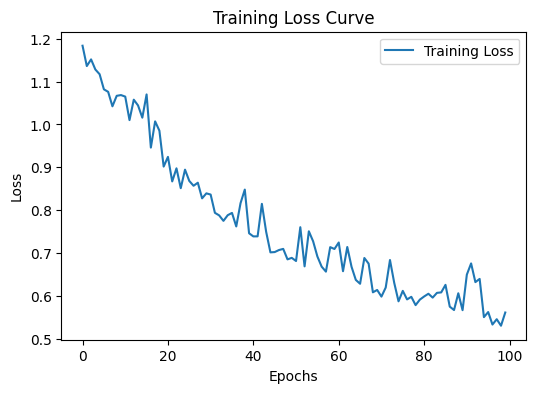

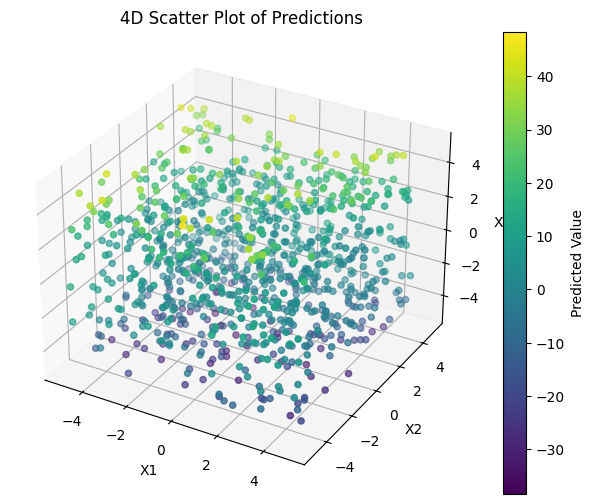

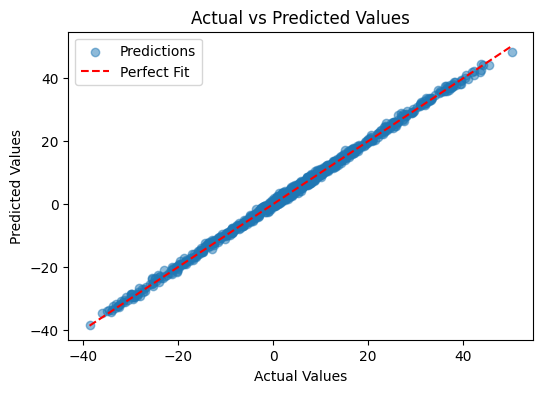

In [10]:
# Train model and store history
history = seq_model.fit(X_train, y_train, epochs=100, batch_size=32)

# Generate predictions from the trained Sequential model
y_pred = seq_model.predict(X_train)

# Plot training loss curve
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')  # ✅ Fixed KeyError
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()

# Plot 4D scatter of predictions
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_pred[:, 0], cmap='viridis')
plt.colorbar(scatter, label='Predicted Value')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('4D Scatter Plot of Predictions')
plt.show()

# Plot Actual vs Predicted Values
plt.figure(figsize=(6, 4))
plt.scatter(y, y_pred, alpha=0.5, label="Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label="Perfect Fit")
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()
